# Relative Rubidium Line fits (Siddons data)

Fits the frequency offset and amplitude scale factor for all other values fixed.

# Relative Sodium Line fits (Steck Data)

Fits the frequency offset and amplitude scale factor for all other values fixed.

## Imports and function definitions

In [132]:
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from lmfit.models import ConstantModel, Model
from pathlib import Path
import pandas as pd
from scipy.constants import Boltzmann as kB
from scipy.constants import speed_of_light as c
from scipy.constants import atomic_mass as au
from scipy.constants import epsilon_0 as e0
from scipy.constants import hbar
from scipy.special import voigt_profile
from scipy.signal import find_peaks

def pressure_torr(temp_K: float) -> float:
    if temp_K < 273+98:
        logp = 133.42927 - 9302.868 / temp_K + \
            0.03114431 * temp_K - 49.37679 * np.log10(temp_K)
    else:
        logp = 10.86423 - 5619.406 / temp_K + 0.00000345 * \
            temp_K - 1.04111  * np.log10(temp_K)
    return 10 ** logp


def number_density(temp_K: float) -> float:
    return 133.323 * pressure_torr(temp_K) / (kB * temp_K)

def transmission_model(x, center, amplitude, sigma, gamma):
    absorption = amplitude * voigt_profile((x-center), sigma, gamma)
    return np.nan_to_num(np.exp(-absorption), nan=0)

## Loading Data and Parameters

In [ ]:

datapath = Path(
    r'/home/mike/Documents/Boulder_PhD/Data/20251023_10h18m12s/rb_cepstral.csv')
data = pd.read_csv(datapath)

# Calculated axis
# full_axis = data['Optical Axis (Hz)'].to_numpy()

# 3 Mode offset per Mathieu's suggestiong
full_axis = data['Optical Axis (Hz)'].to_numpy() + 3e8
full_spectrum = data[' Real Spectrum'].to_numpy()

# Experimental parameters
temp_K = 273+100 
B_field_gauss = .3
cell_length = .075

mass = au * 22.9897692807

nuc_spin_degen = 8

nu0_D1 = 508.3324657e12 
nu0_D2 = 508.8487162e12

Gamma_D1 = 2 * np.pi * 9.765e6
Gamma_D2 = 2 * np.pi * 9.795e6

lam_D1 = 589.7566617e-9
lam_D2 = 589.1583264e-9

dop_sigmav_85 = np.sqrt(kB * temp_K / mass) 
dop_sigmav_87 = np.sqrt(kB * temp_K / mass)

dipole_mat_element_D1 = 3 * \
    np.sqrt(e0 * hbar * Gamma_D1 * lam_D1**3 / (8 * np.pi**2))
dipole_mat_element_D2 = 3 * \
    np.sqrt(e0 * hbar * Gamma_D2 * lam_D2**3 / (8 * np.pi**2))

# line info dict


lines = {'D1': {}, 'D2': {}}

lines['D1']['Fg2Fe1'] = {'center': nu0_D1 - 0.6643597983e9 -118.05e6 - .7e6 * B_field_gauss + .23e6 * B_field_gauss, 'cf2': 5/18}
lines['D1']['Fg2Fe2'] = {'center': nu0_D1 - 0.6643597983e9 + 70.83e6 - .7e6 * B_field_gauss + .23e6 * B_field_gauss, 'cf2': 5/18}

lines['D1']['Fg1Fe1'] = {'center': nu0_D1 + 1.1072663305e9  -118.05e6+ .7e6 * B_field_gauss +.23e6 * B_field_gauss, 'cf2': 1/18}
lines['D1']['Fg1Fe2'] = {'center': nu0_D1  + 1.1072663305e9 + 70.83e6+ .7e6 * B_field_gauss +.23e6 * B_field_gauss, 'cf2': 5/18}

lines['D2']['Fg2Fe1'] = {'center': nu0_D2 - 0.6643597983e9 -50.288e6 -.7e6 * B_field_gauss +.93e6 * B_field_gauss, 'cf2': 1/18}
lines['D2']['Fg2Fe2'] = {'center': nu0_D2 - 0.6643597983e9 -15.944e6 -.7e6 * B_field_gauss +.93e6 * B_field_gauss, 'cf2': 5/18}
lines['D2']['Fg2Fe3'] = {'center': nu0_D2 - 0.6643597983e9 + 42.382e6 -.7e6 * B_field_gauss +.93e6 * B_field_gauss, 'cf2': 7/9}

lines['D2']['Fg1Fe0'] = {'center': nu0_D2 + 1.1072663305e9-66.097e6 +.7e6 * B_field_gauss, 'cf2': 1/9}
lines['D2']['Fg1Fe1'] = {'center': nu0_D2 + 1.1072663305e9-50.288e6+.7e6 * B_field_gauss+.93e6 * B_field_gauss, 'cf2': 5/18}
lines['D2']['Fg1Fe2'] = {'center': nu0_D2 + 1.1072663305e9-15.944e6+.7e6 * B_field_gauss+.93e6 * B_field_gauss, 'cf2': 5/18}

for line, transitions in lines.items():
    for transition, props in transitions.items():
        if line == 'D2':
            props['sigma'] = dop_sigmav_85 * nu0_D2 / c
            props['gamma'] = Gamma_D2/2
            props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * \
                number_density(
                    temp_K) / (nuc_spin_degen * hbar * e0 * dop_sigmav_85)
            # props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * \
                # number_density(
                    # temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
        elif line == 'D1':
            props['sigma'] = dop_sigmav_85 * nu0_D1 / c
            props['gamma'] = Gamma_D1/2
            props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * \
                number_density(
                    temp_K) / (nuc_spin_degen * hbar * e0 * dop_sigmav_85)
            # props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * \
                # number_density(
                    # temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)


## Fit D2s

[[Model]]
    ((((((((((((Model(constant, prefix='bkg_') * Model(transmission_model, prefix='v_Fg3Fe2_85')) * Model(transmission_model, prefix='v_Fg3Fe3_85')) * Model(transmission_model, prefix='v_Fg3Fe4_85')) * Model(transmission_model, prefix='v_Fg2Fe1_85')) * Model(transmission_model, prefix='v_Fg2Fe2_85')) * Model(transmission_model, prefix='v_Fg2Fe3_85')) * Model(transmission_model, prefix='v_Fg2Fe1_87')) * Model(transmission_model, prefix='v_Fg2Fe2_87')) * Model(transmission_model, prefix='v_Fg2Fe3_87')) * Model(transmission_model, prefix='v_Fg1Fe0_87')) * Model(transmission_model, prefix='v_Fg1Fe1_87')) * Model(transmission_model, prefix='v_Fg1Fe2_87'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 35
    # data points      = 121
    # variables        = 3
    chi-square         = 0.01286465
    reduced chi-square = 1.0902e-04
    Akaike info crit   = -1101.03661
    Bayesian info crit = -1092.64924
    R-squared          = 0.99724102
[[Variables]]

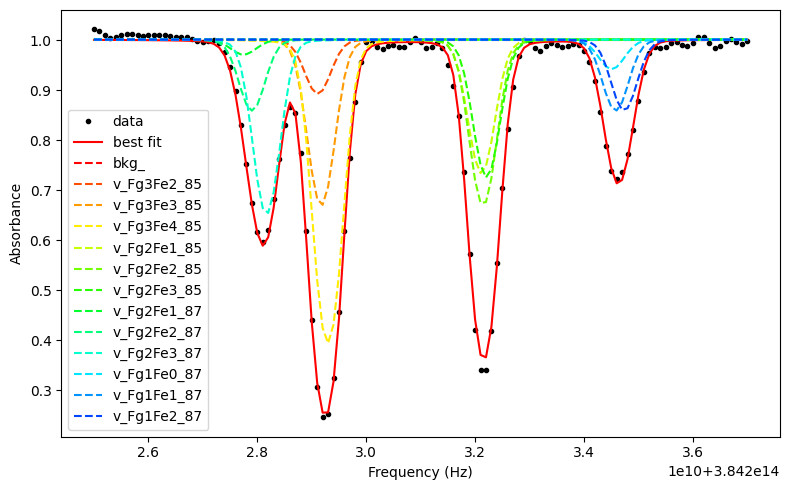

[3.84228059e+14 3.84229196e+14 3.84232104e+14 3.84234579e+14]
[0.58856469 0.24777047 0.35949218 0.71170761]


/home/mike/miniconda3/envs/dev-table/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


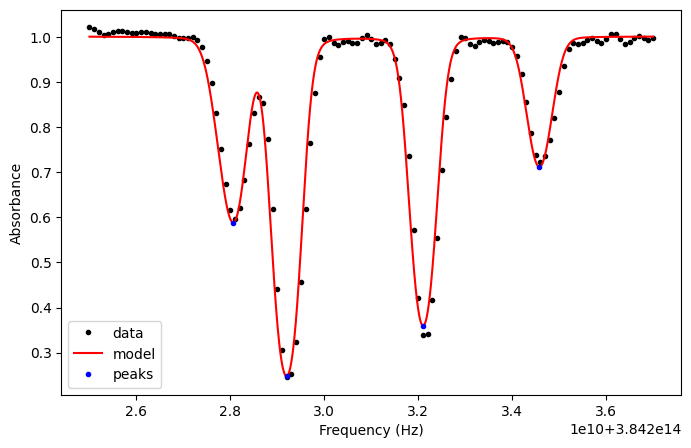

In [ ]:
# D2 Fits ######################################3

mask = (full_axis >= 384.225e12) & (full_axis <= 384.237e12)
axis = full_axis[mask]
spectrum = full_spectrum[mask]
# ---------------------------
# Build composite Voigt model
# ---------------------------
model = ConstantModel(prefix='bkg_')  # background offset
params = model.make_params()

params['bkg_c'].set(value=1)
params.add('xoffset', value=0, min=-500e6, max=500e6)
params.add('amp_scale', value=1e9)
# params.add('Rb87_ratio', value=ratio_87, max=ratio_87+.1, min=ratio_87-.1)

for isotope, transitions in lines['D2'].items():
    for transition, props in transitions.items():
        prefix = f'v_{transition + '_' + isotope}'
        m = Model(transmission_model, prefix=prefix)
        model *= m
        params.update(m.make_params())

        # Give reasonable starting guesses
        params.add(f'{prefix}amp_rel', value=props['absorption'], vary=False)
        params[f'{prefix}sigma'].set(value=props['sigma'], vary=False)
        params[f'{prefix}gamma'].set(value=props['gamma'], vary=False)
        params.add(f'{prefix}center_rel', value=props['center'], vary=False)
        params[f'{prefix}center'].expr = f'{prefix}center_rel + xoffset'
        params[f'{prefix}amplitude'].expr = f'{prefix}amp_rel * amp_scale'

# ---------------------------
# Fit model to data
# ---------------------------
result = model.fit(spectrum, params, x=axis)

# ---------------------------
# Display results
# ---------------------------
print(result.fit_report())

plt.figure(figsize=(8, 5))
plt.plot(axis, spectrum, 'k.', label='data')
plt.plot(axis, result.best_fit, 'r-', label='best fit')

# Plot each individual component
cmap = plt.colormaps['hsv']
colors = cmap(np.linspace(0, 1, 20))
components = result.eval_components(x=axis)
yoffset = components['bkg_']
for i, x in enumerate(components.items()):
    name = x[0]
    comp = x[1]
    if i==0:
        plt.plot(axis, np.real(comp) , '--', label=name, color=colors[i])
    else:
        plt.plot(axis, np.real(comp) *yoffset, '--', label=name, color=colors[i])

plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorbance')
plt.legend()
plt.tight_layout()
plt.show()

# Unshifted line peaks
peak_axis = np.linspace(np.min(axis), np.max(axis), int(1e7))
unshift_params = result.params.copy()
unshift_params['xoffset'].set(value=0)
unshift_spectrum = result.eval(x=peak_axis, params=unshift_params)

peaks_idx, peaks_props = find_peaks(-unshift_spectrum)
peaks_freq = np.array([peak_axis[idx] for idx in peaks_idx])
peaks_amp = result.eval(x=peaks_freq, params=unshift_params)
print(peaks_freq)
print(peaks_amp)
plt.figure(figsize=(8, 5))
plt.plot(axis, spectrum, 'k.', label='data')
plt.plot(peak_axis, unshift_spectrum, 'r-', label='model')
plt.plot(peaks_freq, peaks_amp, 'b.', label = 'peaks')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorbance')
plt.legend()
plt.show()

## Fit D1s

[[Model]]
    ((((((((Model(constant, prefix='bkg_') * Model(transmission_model, prefix='v_Fg3Fe2_85')) * Model(transmission_model, prefix='v_Fg3Fe3_85')) * Model(transmission_model, prefix='v_Fg2Fe2_85')) * Model(transmission_model, prefix='v_Fg2Fe3_85')) * Model(transmission_model, prefix='v_Fg2Fe1_87')) * Model(transmission_model, prefix='v_Fg2Fe2_87')) * Model(transmission_model, prefix='v_Fg1Fe1_87')) * Model(transmission_model, prefix='v_Fg1Fe2_87'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 38
    # data points      = 110
    # variables        = 3
    chi-square         = 0.14218417
    reduced chi-square = 0.00132882
    Akaike info crit   = -725.622372
    Bayesian info crit = -717.520931
    R-squared          = 0.86225315
[[Variables]]
    bkg_c:                  1.02035179 +/- 0.00434760 (0.43%) (init = 1)
    xoffset:               -26306492.6 +/- 14205249.3 (54.00%) (init = 0)
    amp_scale:              14307142.3 +/- 605206.333 (4.23%

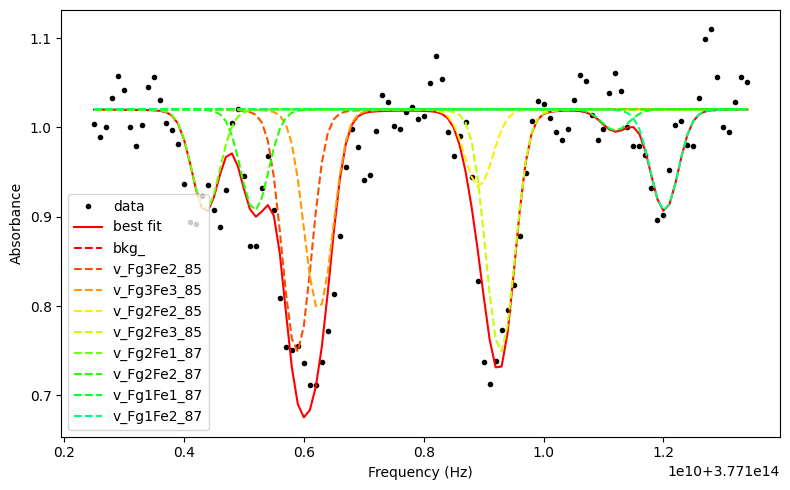

[3.77104392e+14 3.77105228e+14 3.77106037e+14 3.77109275e+14
 3.77111235e+14 3.77112041e+14]
[0.90531179 0.90004736 0.67533636 0.72718654 0.99519354 0.90648654]


/home/mike/miniconda3/envs/dev-table/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


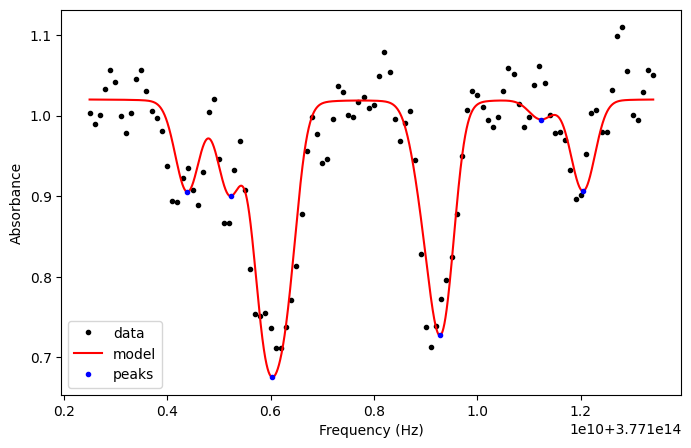

In [ ]:
mask = (full_axis >= nu0_D1 - 5e9) & (full_axis <= nu0_D1 + 6e9) 
axis = full_axis[mask]
spectrum = full_spectrum[mask]
# ---------------------------
# Build composite Voigt model
# ---------------------------
model = ConstantModel(prefix='bkg_')  # background offset
params = model.make_params()

params['bkg_c'].set(value=1)
params.add('xoffset', value=0, min=-500e6, max=500e6)
params.add('amp_scale', value=1e9)

for isotope, transitions in lines['D1'].items():
    for transition, props in transitions.items():
        prefix = f'v_{transition + '_' + isotope}'
        m = Model(transmission_model, prefix=prefix)
        model *= m
        params.update(m.make_params())

        # Give reasonable starting guesses
        params.add(f'{prefix}amp_rel', value=props['absorption'], vary=False)
        params[f'{prefix}sigma'].set(value=props['sigma'], vary=False)
        params[f'{prefix}gamma'].set(value=props['gamma'], vary=False)
        params.add(f'{prefix}center_rel', value=props['center'], vary=False)
        params[f'{prefix}center'].expr = f'{prefix}center_rel + xoffset'
        params[f'{prefix}amplitude'].expr = f'{prefix}amp_rel * amp_scale'

# ---------------------------
# Fit model to data
# ---------------------------
result = model.fit(spectrum, params, x=axis)

# ---------------------------
# Display results
# ---------------------------
print(result.fit_report())

yoffset = result.params['bkg_c'].value
# xoffset = result.params['xoffset'].value
xoffset=0

plt.figure(figsize=(8, 5))
plt.plot(axis, spectrum, 'k.', label='data')
plt.plot(axis-xoffset, result.best_fit, 'r-', label='best fit')

# Plot each individual component
cmap = plt.colormaps['hsv']
colors = cmap(np.linspace(0, 1, 20))

components = result.eval_components(x=axis)
for i, x in enumerate(components.items()):
    name = x[0]
    comp = x[1]
    if i==0:
        plt.plot(axis-xoffset, np.real(comp) , '--', label=name, color=colors[i])
    else:
        plt.plot(axis-xoffset, np.real(comp) *yoffset, '--', label=name, color=colors[i])

plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorbance')
plt.legend()
plt.tight_layout()
plt.show()

# Unshifted line peaks
peak_axis = np.linspace(np.min(axis), np.max(axis), int(1e7))
unshift_params = result.params.copy()
unshift_params['xoffset'].set(value=0)
unshift_spectrum = result.eval(x=peak_axis, params=unshift_params)

peaks_idx, peaks_props = find_peaks(-unshift_spectrum)
peaks_freq = np.array([peak_axis[idx] for idx in peaks_idx])
peaks_amp = result.eval(x=peaks_freq, params=unshift_params)
print(peaks_freq)
print(peaks_amp)
plt.figure(figsize=(8, 5))
plt.plot(axis, spectrum, 'k.', label='data')
plt.plot(peak_axis, unshift_spectrum, 'r-', label='model')
plt.plot(peaks_freq, peaks_amp, 'b.', label = 'peaks')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorbance')
plt.legend()
plt.show()

# Relative Rubidium Line fits (Steck Data)

Fits the frequency offset and amplitude scale factor for all other values fixed.

## Imports and function definitions

In [ ]:
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from lmfit.models import ConstantModel, Model
from pathlib import Path
import pandas as pd
from scipy.constants import Boltzmann as kB
from scipy.constants import speed_of_light as c
from scipy.constants import atomic_mass as au
from scipy.constants import epsilon_0 as e0
from scipy.constants import hbar
from scipy.special import voigt_profile
from scipy.signal import find_peaks

def pressure_torr(temp_K: float) -> float:
    if temp_K < 273 + 39.31:
        logp = - 94.04826 - 1961.258 / temp_K - \
            0.03771687 * temp_K + 42.57526 * np.log10(temp_K)
    else:
        logp = 15.88253 - 4529.635 / temp_K + 0.00058663 * \
            temp_K - 2.99138 * np.log10(temp_K)
    return 10 ** logp


def number_density(temp_K: float) -> float:
    return 133.323 * pressure_torr(temp_K) / (kB * temp_K)

def transmission_model(x, center, amplitude, sigma, gamma):
    absorption = amplitude * voigt_profile((x-center), sigma, gamma)
    return np.nan_to_num(np.exp(-absorption), nan=0)

## Loading Data and Parameters

In [128]:

# datapath = Path(
    # r'/home/mike/Documents/Boulder_PhD/Data/20251030_15h49m14s/rb_cepstral.csv')
datapath = Path(
    r'/home/mike/Documents/Boulder_PhD/Data/20251023_10h18m12s/rb_cepstral.csv')
data = pd.read_csv(datapath)

# Calculated axis
# full_axis = data['Optical Axis (Hz)'].to_numpy()

# 3 Mode offset per Mathieu's suggestiong
full_axis = data['Optical Axis (Hz)'].to_numpy() + 3e8
full_spectrum = data[' Real Spectrum'].to_numpy()

# Experimental parameters
temp_K = 273+40 
B_field_gauss = .3
cell_length = .075

mass_85 = au * 84.911789732
mass_87 = au * 86.909180520

ratio_85 = .7217
ratio_87 = 1- ratio_85

nuc_spin_degen_85 = 12
nuc_spin_degen_87 = 8

nu0_D1_85 = 377.10738569e12
nu0_D2_85 = 384.23040637e12

nu0_D1_87 = 377.1074635e12
nu0_D2_87 = 384.2304844685e12

Gamma_D1 = 2 * np.pi * 5.746e6
Gamma_D2 = 2 * np.pi * 6.065e6

lam_D1 = 794.979e-9
lam_D2 = 780.241e-9

dop_sigmav_85 = np.sqrt(kB * temp_K / mass_85) 
dop_sigmav_87 = np.sqrt(kB * temp_K / mass_87)

dipole_mat_element_D1 = 3 * \
    np.sqrt(e0 * hbar * Gamma_D1 * lam_D1**3 / (8 * np.pi**2))
dipole_mat_element_D2 = 3 * \
    np.sqrt(e0 * hbar * Gamma_D2 * lam_D2**3 / (8 * np.pi**2))

# D2 dict

isotopes = {'85': {}, '87': {}}
lines = {'D1': deepcopy(isotopes), 'D2': deepcopy(isotopes)}

lines['D1']['87']['Fg2Fe1'] = {'center': nu0_D1_87 - 2.5630059790891e9 -510.410e6 - .7e6 * B_field_gauss + .23e6 * B_field_gauss, 'cf2': 5/18}
lines['D1']['87']['Fg2Fe2'] = {'center': nu0_D1_87 - 2.5630059790891e9 +306.246e6 - .7e6 * B_field_gauss + .23e6 * B_field_gauss, 'cf2': 5/18}

lines['D1']['85']['Fg3Fe2'] = {'center': nu0_D1_85 - 1.2648885163e9 -210.923e6 -.47e6 * B_field_gauss -.16e6 * B_field_gauss, 'cf2': 35/81}
lines['D1']['85']['Fg3Fe3'] = {'center': nu0_D1_85 - 1.2648885163e9 + 150.659e6 -.47e6 * B_field_gauss +.16e6 * B_field_gauss, 'cf2': 28/81}

lines['D1']['85']['Fg2Fe2'] = {'center': nu0_D1_85 + 1.7708439228e9 -210.923e6+.47e6 * B_field_gauss -.16e6 * B_field_gauss, 'cf2': 10/81}
lines['D1']['85']['Fg2Fe3'] = {'center': nu0_D1_85 + 1.7708439228e9 + 150.659e6+.47e6 * B_field_gauss +.16e6 * B_field_gauss, 'cf2': 35/81}

lines['D1']['87']['Fg1Fe1'] = {'center': nu0_D1_87 + 4.2716766318151e9 -510.410e6 + .7e6 * B_field_gauss +.23e6 * B_field_gauss, 'cf2': 1/18}
lines['D1']['87']['Fg1Fe2'] = {'center': nu0_D1_87  +4.2716766318151e9+306.246e6+ .7e6 * B_field_gauss +.23e6 * B_field_gauss, 'cf2': 5/18}

lines['D2']['87']['Fg2Fe1'] = {'center': nu0_D2_87 - 2.56300597908911e9 -229.8518e6 -.7e6 * B_field_gauss +.93e6 * B_field_gauss, 'cf2': 1/18}
lines['D2']['87']['Fg2Fe2'] = {'center': nu0_D2_87 - 2.56300597908911e9- 72.9113e6 -.7e6 * B_field_gauss +.93e6 * B_field_gauss, 'cf2': 5/18}
lines['D2']['87']['Fg2Fe3'] = {'center': nu0_D2_87  - 2.56300597908911e9+193.7408e6 -.7e6 * B_field_gauss +.93e6 * B_field_gauss, 'cf2': 7/9}

lines['D2']['85']['Fg3Fe2'] = {'center': nu0_D2_85 - 1.264888516e9 -83.955e6  -.47e6 * B_field_gauss +.16e6* B_field_gauss, 'cf2': 10/81}
lines['D2']['85']['Fg3Fe3'] = {'center': nu0_D2_85 - 1.264888516e9 - 20.503e6 -.47e6 * B_field_gauss +.54e6* B_field_gauss, 'cf2': 35/81}
lines['D2']['85']['Fg3Fe4'] = {'center': nu0_D2_85 - 1.264888516e9+ 100.357e6 -.47e6 * B_field_gauss +.70e6* B_field_gauss, 'cf2': 1}

lines['D2']['85']['Fg2Fe1'] = {'center': nu0_D2_85 +1.770843922e9 -113.307e6 +.47e6 * B_field_gauss -1.4e6 * B_field_gauss, 'cf2': 1/3}
lines['D2']['85']['Fg2Fe2'] = {'center': nu0_D2_85 +1.770843922e9-83.955e6+.47e6 * B_field_gauss +.16e6 * B_field_gauss, 'cf2': 35/81}
lines['D2']['85']['Fg2Fe3'] = {'center': nu0_D2_85 +1.770843922e9- 20.503e6+.47e6 * B_field_gauss +.54e6 * B_field_gauss, 'cf2': 28/81}

lines['D2']['87']['Fg1Fe0'] = {'center': nu0_D2_87 +4.27167663181519e9 -302.0738e6 +.7e6 * B_field_gauss, 'cf2': 1/9}
lines['D2']['87']['Fg1Fe1'] = {'center': nu0_D2_87 +4.27167663181519e9-229.8518e6+.7e6 * B_field_gauss+.93e6 * B_field_gauss, 'cf2': 5/18}
lines['D2']['87']['Fg1Fe2'] = {'center': nu0_D2_87 +4.27167663181519e9 - 72.9113e6+.7e6 * B_field_gauss+.93e6 * B_field_gauss, 'cf2': 5/18}

for line, isotopes in lines.items():
    for isotope, transitions in isotopes.items():
        for transition, props in transitions.items():
            if isotope == '85':
                if line == 'D2':
                    props['sigma'] = dop_sigmav_85 * nu0_D2 / c
                    props['gamma'] = Gamma_D2/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * ratio_85 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
                    # props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * \
                        # number_density(
                            # temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
                elif line == 'D1':
                    props['sigma'] = dop_sigmav_85 * nu0_D1 / c
                    props['gamma'] = Gamma_D1/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * ratio_85 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
                    # props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * \
                        # number_density(
                            # temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
            elif isotope == '87':
                if line == 'D2':
                    props['sigma'] = dop_sigmav_87 * nu0_D2 / c
                    props['gamma'] = Gamma_D2/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * ratio_87 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_87 * hbar * e0 * dop_sigmav_87)
                    # props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * \
                        # number_density(
                            # temp_K) / (nuc_spin_degen_87 * hbar * e0 * dop_sigmav_87)
                elif line == 'D1':
                    props['sigma'] = dop_sigmav_87 * nu0_D1 / c
                    props['gamma'] = Gamma_D1/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * ratio_87 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_87 * hbar * e0 * dop_sigmav_87)
                    # props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * \
                        # number_density(
                            # temp_K) / (nuc_spin_degen_87 * hbar * e0 * dop_sigmav_87)


## Fit D2s

[[Model]]
    ((((((((((((Model(constant, prefix='bkg_') * Model(transmission_model, prefix='v_Fg3Fe2_85')) * Model(transmission_model, prefix='v_Fg3Fe3_85')) * Model(transmission_model, prefix='v_Fg3Fe4_85')) * Model(transmission_model, prefix='v_Fg2Fe1_85')) * Model(transmission_model, prefix='v_Fg2Fe2_85')) * Model(transmission_model, prefix='v_Fg2Fe3_85')) * Model(transmission_model, prefix='v_Fg2Fe1_87')) * Model(transmission_model, prefix='v_Fg2Fe2_87')) * Model(transmission_model, prefix='v_Fg2Fe3_87')) * Model(transmission_model, prefix='v_Fg1Fe0_87')) * Model(transmission_model, prefix='v_Fg1Fe1_87')) * Model(transmission_model, prefix='v_Fg1Fe2_87'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 35
    # data points      = 121
    # variables        = 3
    chi-square         = 0.01286465
    reduced chi-square = 1.0902e-04
    Akaike info crit   = -1101.03661
    Bayesian info crit = -1092.64924
    R-squared          = 0.99724102
[[Variables]]

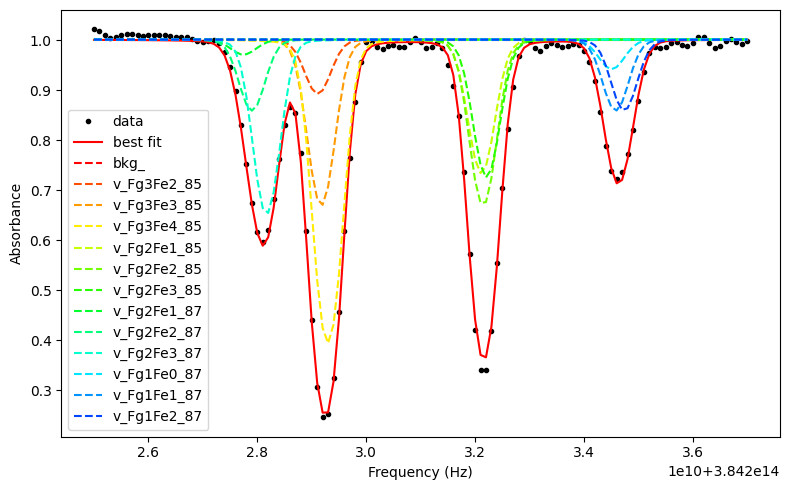

[3.84228059e+14 3.84229196e+14 3.84232104e+14 3.84234579e+14]
[0.58856469 0.24777047 0.35949218 0.71170761]


/home/mike/miniconda3/envs/dev-table/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


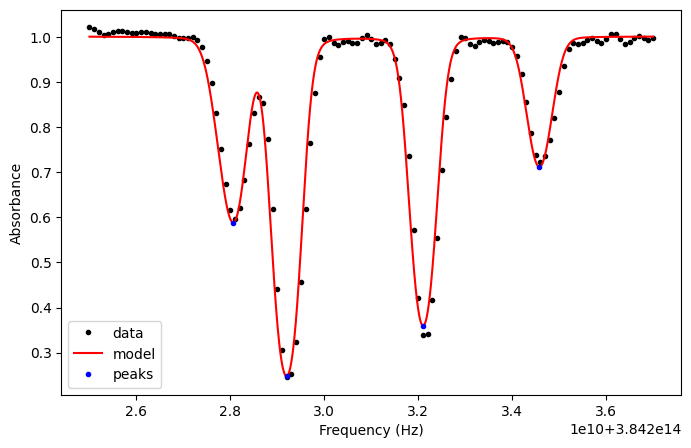

In [129]:
# D2 Fits ######################################3

mask = (full_axis >= 384.225e12) & (full_axis <= 384.237e12)
axis = full_axis[mask]
spectrum = full_spectrum[mask]
# ---------------------------
# Build composite Voigt model
# ---------------------------
model = ConstantModel(prefix='bkg_')  # background offset
params = model.make_params()

params['bkg_c'].set(value=1)
params.add('xoffset', value=0, min=-500e6, max=500e6)
params.add('amp_scale', value=1e9)
# params.add('Rb87_ratio', value=ratio_87, max=ratio_87+.1, min=ratio_87-.1)

for isotope, transitions in lines['D2'].items():
    for transition, props in transitions.items():
        prefix = f'v_{transition + '_' + isotope}'
        m = Model(transmission_model, prefix=prefix)
        model *= m
        params.update(m.make_params())

        # Give reasonable starting guesses
        params.add(f'{prefix}amp_rel', value=props['absorption'], vary=False)
        params[f'{prefix}sigma'].set(value=props['sigma'], vary=False)
        params[f'{prefix}gamma'].set(value=props['gamma'], vary=False)
        params.add(f'{prefix}center_rel', value=props['center'], vary=False)
        params[f'{prefix}center'].expr = f'{prefix}center_rel + xoffset'
        params[f'{prefix}amplitude'].expr = f'{prefix}amp_rel * amp_scale'

# ---------------------------
# Fit model to data
# ---------------------------
result = model.fit(spectrum, params, x=axis)

# ---------------------------
# Display results
# ---------------------------
print(result.fit_report())

plt.figure(figsize=(8, 5))
plt.plot(axis, spectrum, 'k.', label='data')
plt.plot(axis, result.best_fit, 'r-', label='best fit')

# Plot each individual component
cmap = plt.colormaps['hsv']
colors = cmap(np.linspace(0, 1, 20))
components = result.eval_components(x=axis)
yoffset = components['bkg_']
for i, x in enumerate(components.items()):
    name = x[0]
    comp = x[1]
    if i==0:
        plt.plot(axis, np.real(comp) , '--', label=name, color=colors[i])
    else:
        plt.plot(axis, np.real(comp) *yoffset, '--', label=name, color=colors[i])

plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorbance')
plt.legend()
plt.tight_layout()
plt.show()

# Unshifted line peaks
peak_axis = np.linspace(np.min(axis), np.max(axis), int(1e7))
unshift_params = result.params.copy()
unshift_params['xoffset'].set(value=0)
unshift_spectrum = result.eval(x=peak_axis, params=unshift_params)

peaks_idx, peaks_props = find_peaks(-unshift_spectrum)
peaks_freq = np.array([peak_axis[idx] for idx in peaks_idx])
peaks_amp = result.eval(x=peaks_freq, params=unshift_params)
print(peaks_freq)
print(peaks_amp)
plt.figure(figsize=(8, 5))
plt.plot(axis, spectrum, 'k.', label='data')
plt.plot(peak_axis, unshift_spectrum, 'r-', label='model')
plt.plot(peaks_freq, peaks_amp, 'b.', label = 'peaks')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorbance')
plt.legend()
plt.show()

## Fit D1s

[[Model]]
    ((((((((Model(constant, prefix='bkg_') * Model(transmission_model, prefix='v_Fg3Fe2_85')) * Model(transmission_model, prefix='v_Fg3Fe3_85')) * Model(transmission_model, prefix='v_Fg2Fe2_85')) * Model(transmission_model, prefix='v_Fg2Fe3_85')) * Model(transmission_model, prefix='v_Fg2Fe1_87')) * Model(transmission_model, prefix='v_Fg2Fe2_87')) * Model(transmission_model, prefix='v_Fg1Fe1_87')) * Model(transmission_model, prefix='v_Fg1Fe2_87'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 38
    # data points      = 110
    # variables        = 3
    chi-square         = 0.14218417
    reduced chi-square = 0.00132882
    Akaike info crit   = -725.622372
    Bayesian info crit = -717.520931
    R-squared          = 0.86225315
[[Variables]]
    bkg_c:                  1.02035179 +/- 0.00434760 (0.43%) (init = 1)
    xoffset:               -26306492.6 +/- 14205249.3 (54.00%) (init = 0)
    amp_scale:              14307142.3 +/- 605206.333 (4.23%

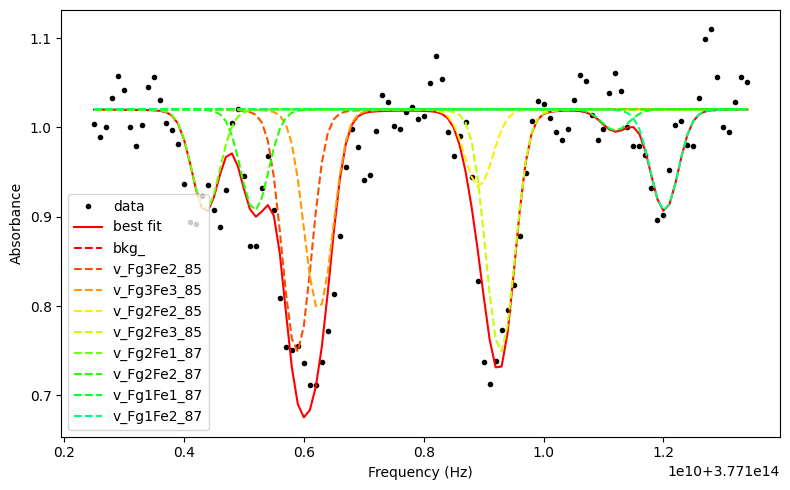

[3.77104392e+14 3.77105228e+14 3.77106037e+14 3.77109275e+14
 3.77111235e+14 3.77112041e+14]
[0.90531179 0.90004736 0.67533636 0.72718654 0.99519354 0.90648654]


/home/mike/miniconda3/envs/dev-table/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


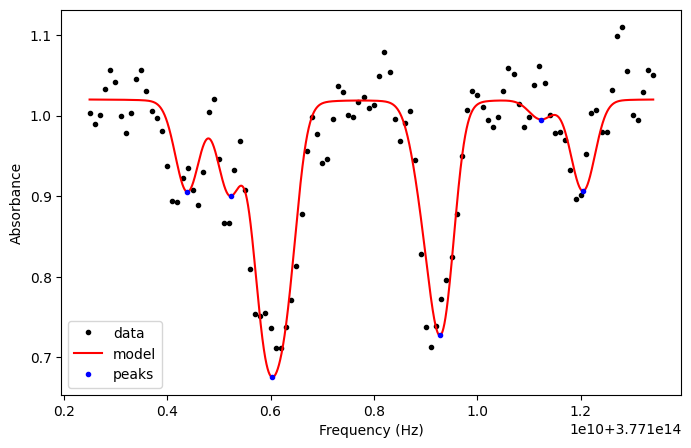

In [130]:
mask = (full_axis >= nu0_D1 - 5e9) & (full_axis <= nu0_D1 + 6e9) 
axis = full_axis[mask]
spectrum = full_spectrum[mask]
# ---------------------------
# Build composite Voigt model
# ---------------------------
model = ConstantModel(prefix='bkg_')  # background offset
params = model.make_params()

params['bkg_c'].set(value=1)
params.add('xoffset', value=0, min=-500e6, max=500e6)
params.add('amp_scale', value=1e9)

for isotope, transitions in lines['D1'].items():
    for transition, props in transitions.items():
        prefix = f'v_{transition + '_' + isotope}'
        m = Model(transmission_model, prefix=prefix)
        model *= m
        params.update(m.make_params())

        # Give reasonable starting guesses
        params.add(f'{prefix}amp_rel', value=props['absorption'], vary=False)
        params[f'{prefix}sigma'].set(value=props['sigma'], vary=False)
        params[f'{prefix}gamma'].set(value=props['gamma'], vary=False)
        params.add(f'{prefix}center_rel', value=props['center'], vary=False)
        params[f'{prefix}center'].expr = f'{prefix}center_rel + xoffset'
        params[f'{prefix}amplitude'].expr = f'{prefix}amp_rel * amp_scale'

# ---------------------------
# Fit model to data
# ---------------------------
result = model.fit(spectrum, params, x=axis)

# ---------------------------
# Display results
# ---------------------------
print(result.fit_report())

yoffset = result.params['bkg_c'].value
# xoffset = result.params['xoffset'].value
xoffset=0

plt.figure(figsize=(8, 5))
plt.plot(axis, spectrum, 'k.', label='data')
plt.plot(axis-xoffset, result.best_fit, 'r-', label='best fit')

# Plot each individual component
cmap = plt.colormaps['hsv']
colors = cmap(np.linspace(0, 1, 20))

components = result.eval_components(x=axis)
for i, x in enumerate(components.items()):
    name = x[0]
    comp = x[1]
    if i==0:
        plt.plot(axis-xoffset, np.real(comp) , '--', label=name, color=colors[i])
    else:
        plt.plot(axis-xoffset, np.real(comp) *yoffset, '--', label=name, color=colors[i])

plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorbance')
plt.legend()
plt.tight_layout()
plt.show()

# Unshifted line peaks
peak_axis = np.linspace(np.min(axis), np.max(axis), int(1e7))
unshift_params = result.params.copy()
unshift_params['xoffset'].set(value=0)
unshift_spectrum = result.eval(x=peak_axis, params=unshift_params)

peaks_idx, peaks_props = find_peaks(-unshift_spectrum)
peaks_freq = np.array([peak_axis[idx] for idx in peaks_idx])
peaks_amp = result.eval(x=peaks_freq, params=unshift_params)
print(peaks_freq)
print(peaks_amp)
plt.figure(figsize=(8, 5))
plt.plot(axis, spectrum, 'k.', label='data')
plt.plot(peak_axis, unshift_spectrum, 'r-', label='model')
plt.plot(peaks_freq, peaks_amp, 'b.', label = 'peaks')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorbance')
plt.legend()
plt.show()